Josh Brewington and Alex Roy

<center>

<font color='blue'/><h3 style="text-align:center; color:blue">Lab11 (Part II) :Implementing an Adaptive Linear Neuron and Gradient Descent in Python</h3>
    
<h3 style="text-align:center; color:blue";>(Supervised Learning: Classification of the SciKit Learn Digits Dataset) </h3>
</center>



<img src="images/adaline.png" width =300; height = 300>

## Objectives
* Reuse and modify code from previous labs
* Understand and Implement Gradient Descent in Python
* Extend the MCP and Rosenblatt Perceptron model developed in Python to include Gradient Descent
 * Implement this ADAptive LInear NEuron classifier (Adaline) and Gradient Descent in Python
* Mathematically Extend the Perceptron Binary Model to a MultiClass Model (Numpy Linear Algebra)
* Use the Python Programming Language to Implement Frank Rosenblatt’s perceptron learning rule based on the MCP neuron model.
* Use NumPy matrix products and other Numpy features (arrays and methods) to create a subset of handwritten digits
* Train the Adaline model for multiclass classification on subset of handwritten digits

* Create Predictive Models
* Perform Model Evaluation
    * Model Score and Accuracy
    * Confusion Matrix
* Plot the Cost (loss) Function

## <font color='orange'/>Class Adaline with Gradient Descent in Python

As we indicated in Part I, the Perceptron rule and the Adaline rule are very similar. To implement the Adaline learning rule, we only need to take the Perceptron Class that we used earlier and modify the fit method so that the weights are updated by minimizing the cost function by gradient descent. The COMPLETE Python Class for implementing Adaline using gradient descent is:
<img src="images/class_adaline.png" width = 600; height = 300>

### <font color = 'green'/>1-TO DO : Carefully enter the code for the Python class AdalineGD in the empty cell below the heading.
#### <font color='blue'/>Make sure you examine and understand every line of code in the AdalineGD class after you enter it below

### <font color='red'/> class Adaline: <font color='blue'/>Implementing an Adaptive Linear Neuron in Python
#### <font color='blue'/> Minimizing cost functions with gradient descent

In [1]:
class AdalineGD(object):
    """ADAptive Linear NEuron classifer.
    Parameters
    ------------
    eta : float
    Learning rate (between 0.0 and 1.0)
    n_iter : int Passes over the training dataset.
    random_state : int
    Random number generator seed for random weight initialization.
    Attributes
    -----------
    w_ : 2d-array
    Weights after fitting.
    cost_ : list
    Sum-of-squares cost function value in each epoch.
    """
    
    
    
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        
    def fit(self, X, y):
        """Fit training data.
        Parameters
        ----------
        X : {array-like}, shape = [n_samples, n_features]
        Training vectors, where n_samples is the nimber of
        samples and
        n_features is the number of features.
        y : array-lke, shape = [n_samples]
        Target values.
        Returns
        -------
        self : object
        """
        #initialize weights to small random numbers
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        
        self.cost_ = []
        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            # cost function in python .sum() is summation
            self.cost_.append(cost)
        return self
    
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]
    
    def activation(self, X):
        """Compute linear activation"""
        return X
    
    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X))>= 0.0, 1, 0)

    
    
    
    
    
#We have to add a method of scoring accuracy right here, I think it's in a prior lab. 
#Pretty sure it went like def score(self, x, y): then y_pred = predict(X), then return np.mean_count(y_pred == y) or something.
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

<img src= "images/converge_diverge_models.png" width=700>


### <font color='green'/> Standard imports

In [2]:
# Standard scientific Python imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# <font color='orange'/>Using the MNIST Dataset with the Perceptron Classification Model 
When one learns how to program, there's a tradition that the first thing you do is print "Hello World." Just like programming has Hello World, machine learning has MNIST.

MNIST is a simple computer vision dataset. It consists of images of handwritten digits like these:
<center>
    <img src="images/mnist_image.png" width=250; height=200>
</center>

It also includes labels for each image, telling us which digit it is. For example, the labels for the above images are 5, 0, 4, and 1.

###  <font color='green'/> 2-TO DO: Loading Data
Use `Pandas` to load MNIST data into a dataframe. <font color='red'/> Name the dataframe df_mnist. Also display the entire dataset in the second cell.

In [3]:
df_mnist = pd.read_csv('mnist_datasets/mnist_784.csv',  low_memory=False)

###### <font color='orange'/>Code to dispaly the entire data in the dataframe has been provided for you below

In [4]:
df_mnist

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


### <font color='green'/> 3-TO DO:Print the Shape of the data
print the shape of the data in the *dataframe* in the cell below

In [5]:
df = pd.read_csv('mnist_datasets/mnist_784.csv')
df.shape

# printing out the shape to find 70,000 rows and 785 columns
# 784 features and 1 target vector
# the features represent the intensity of each pixel, and the target vector is what number is actually being visually represented

(70000, 785)

There are 70,000 images and each image has 784 features (each image is 28 x 28 pixels and each pixel represents a feature of an image). Each image of the MNIST dataset is encoded in a 784 dimensional vector, representing a 28 x 28 pixel image. Each pixel has a value between 0 and 255, representing the pixel's intensity, from 0 (white) to 255 (black) corresponding to the grey-value of a pixel.
###### <font color='red'/>make sure you understand why the shape is displaying that there are 785 columns!

### <font color='green'/> 4-TO DO: Processing Data
In the cell below, use Pandas `loc` to create the feature matrix and column vector. This can be done as follows to create the *feature matrix*:

Since the last column in the dataset is the *class* attribute , we need to select all columns except one column in Pandas DataFrame. To do this we can use  `df.loc[:, df.columns != <column name>]` as follows:

#### <font color='green'/>  Steps

1)  Initialize a variable *col* with column name that you want to exclude.

2)  Use `df.loc[:, df.columns != col]` to create another DataFrame excluding a particular column.

3) To make sure you have extracted the columns you expect, you can print the DataFrame without `col` column.
###### <font color='red'/>WARNING: We need these to be numpy arrays so make sure you convert them during this process. See your labs, etc.

In [6]:
#create feature matrix and target vector from dataframe
col = 'class'
# varaible set to class for target vector
#excluding class from the feature matrix
X = df.loc[:, df.columns != col].to_numpy()
y = df[col].to_numpy()
print(f'The shape of the features are: {X.shape}')
print(f'The target vector shape is: {y.shape}')

The shape of the features are: (70000, 784)
The target vector shape is: (70000,)


### <font color='green'/> 5-TO DO: Simple Data Exploration for Images

In the cell below print the following:
```python
print('This is how X[0] looks when "flattened" \n{}'.format(X[0]))
print ('\nThis is how X[0] looks when "reshaped" to image format \n{}'.format(X[0].reshape(28,28)))
print('\nThis is simply the target vector value that is associated with the image {}'.format(y[0]))
```
###### <font color='orange'/>You should take a moment and look at the output. Notice which are 1D or 2D arrays and the values they hold

In [7]:
print('This is how X[0] looks when "flattened" \n{}'.format(X[0]))
# This is when the values are disaggregated linear and stacked in each value place
# Can use any index position to display the matrix

print ('\nThis is how X[0] looks when "reshaped" to image format \n{}'.format(X[0].reshape(28,28)))
# This is where that same feature matrix is called but in a 28x28 matrix arrangement
# the 28x28 shape represents the image per pixels

print('\nThis is simply the target vector value that is associated with the first image: {}'.format(y[0]))
# These are the from the attribute 'class'

This is how X[0] looks when "flattened" 
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 2

###  <font color='green'/> 6-TO DO:Create a subset of the digits data using only the *zeroes and ones* 

<font color='red'/>COMMENT: I have done this part for you but you should make sure you understand what the code does and how the subset of images is being created from the larger dataset. DO NOT ALTER THIS CODE UNLESS YOU ARE ASKED TO. **YOU MUST USE THE VARIABLE NAMES GIVEN!**

In [8]:
zero_one_indices = np.sort(np.concatenate((np.where(y == 0)[0], np.where(y == 1)[0])))
#picking out the y=1s and y=0s

In [9]:
zero_one_images = X[zero_one_indices] 
zero_one_labels = y[zero_one_indices]
zero_one_labels.shape


(14780,)

### <font color='green'/>7- TO DO:  display an image
Display the image with index = 11

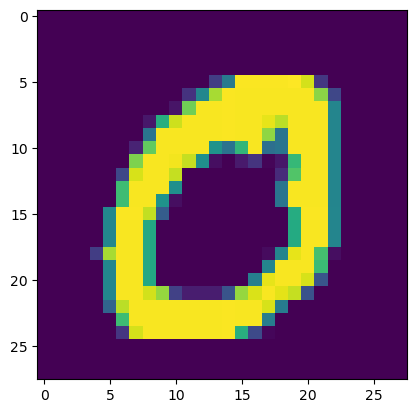

In [10]:
# This shows the image equating to index positon 11
plt.imshow(zero_one_images[11].reshape(28, 28))


plt.show()

### <font color='green'/>8- TO DO: Is the Training Dataset Balanced?
#### <font color='blue'/> Data Visualization
Plot a histogram of the dataset *class labels* to make sure we have a balanced dataset, i.e. we want to figure out how often each number is represented in the dataset. This is important when we are trying to eliminate **algorithmic bias** in our machine learning models. <font color='red'/>WARNING: Your code should be general and should be able to plot *any* two digits selected as the subset.

([<matplotlib.axis.XTick at 0x15e4a81f4f0>,
 [Text(0, 0, ''), Text(0, 0, '')])

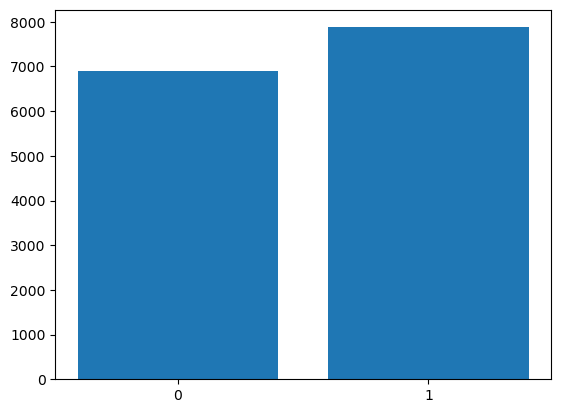

In [11]:
# extract any number in the dataset, this is creating a list of y values 0 and 2
subset = zero_one_labels
plt.bar(np.unique(subset), np.bincount(subset))
plt.xticks([0, 1])


### <font color='green'/>9-TO DO:Split the data into Training and Testing Sets
Scikit learn contains a function called the **train_test_split** function  that will randomly shuffle the dataset and then splits it into two datasets: a **training set** used to build the model and a **test set** to assess and evaluate how well the model works on unseen data. **Use a 75%/25% train-test split**. 
<br><br><font color='red'/>You should also use `shuffle=True` and `random_state=0` in your split.

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(zero_one_images, zero_one_labels, test_size=0.25, random_state=0,
                                                      shuffle = True)

### <font color='green'/> 10- TO DO:Look at the *shape* of the data (rows and columns) *after* splitting it into training and testing sets
**Enter your code in the next TWO cells below**

In [13]:
print(f'The shape of the X training set is {X_train.shape}')
print(f'The shape of the y training set is {y_train.shape}')

The shape of the X training set is (11085, 784)
The shape of the y training set is (11085,)


In [14]:
print(f'The shape of the X testing set is {X_test.shape}')
print(f'The shape of the y testing set is {y_test.shape}')

The shape of the X testing set is (3695, 784)
The shape of the y testing set is (3695,)


### <font color='green'>11- TO DO: Code to plot several images</font>
<font color='red'/>COMMENT: I have done this part for you. I have created it as a callable function since we will need to use it later. You should make sure you understand what the code does and how the subset of images is being plotted

In [15]:
def plot_example(X, y):
    """Plot the first 5 images and their labels in a row."""
    plt.subplots(figsize=(9, 4))
    for i, (img, y) in enumerate(zip(X[:5].reshape(5, 28, 28), y[:5])):
        #subplot five images on one row
        plt.subplot(1, 5, i+1) 
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(y)
    plt.show()

call the function to plot a subset of images in the training set

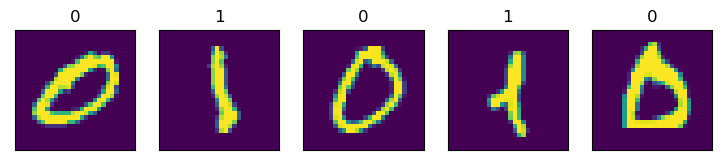

In [16]:
plot_example(X_train, y_train)

### <font color='blue'/> Scaling the features of a dataset 

<h4 style="text-align:left; color:red";>IMPORTANT: Standardizing the features:</h4>

* There are two common approaches to bring different features onto the same scale: **normalization** and **standardization**.  Most often, normalization refers to the rescaling of the features to a range of [0, 1], which is a special case of min-max scaling. To normalize our data, we can simply apply the min-max scaling to each feature column.

* Standardization of datasets (feature scaling) is a common requirement for many machine learning and optimization algorithms implemented in scikit-learn; they might behave badly if the individual features do not more or less look like standard normally distributed data, i.e., Gaussian with zero mean and unit variance.

### <font color='green'/>12-TO DO Scale the Data
##### Use the scikit-learn  MinMaxScaler to scale the training and testing datasets

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

#MinMaxScaler = MinMaxScaler()
#MinMaxScaler.fit(X_train)
#X_train_rescaled = MinMaxScaler.transform(X_train)
#X_test_rescaled = MinMaxScaler.transform(X_test)

scaler = StandardScaler()
    # set a variable 'scaler' to StandardScaler()

scaler.fit(X_train)
X_train_rescaled = scaler.transform(X_train)
    # scaler variable called to transform features training set

X_test_rescaled = scaler.transform(X_test)
print(f'The X_train rescaled is: {X_train_rescaled.shape}')
print(f'The X_test rescaled is: {X_test_rescaled.shape}')

The X_train rescaled is: (11085, 784)
The X_test rescaled is: (3695, 784)


### <font color='green'/>13-TO DO: Build Adaptive Linear Neuron Model
#### Instantiate the AdalineGD class train the model on the data. Use the following variable names and range of parameters:

#### The Model using the Adaline Classifier:

- model name  = ada
- n_iter = you choose: must be in range 100 to 1000
- eta = you choose: must be in range, 1.0e-4 to 1.0e-8
- random_state = 1

You can use the default values for the rest of the parameters. <font color='red'/>Your model MUST converge with accuracy > 90%

In [18]:
#from sklearn.linear_model import SGDClassifier


    
ada = AdalineGD(n_iter=900, eta=0.0000001, random_state=1).fit(X_train_rescaled, y_train)
        
ada.fit(X_train_rescaled, y_train)
        

y_pred = ada.predict(X_test_rescaled)
print("Test set score: {0:0.2f}".format(np.mean(y_pred==y_test)))
print("Test set score (accuracy on test set): {0:0.2f}".format(ada.score(X_test_rescaled,y_test)))

# No fuckin Idea


Test set score: 0.96
Test set score (accuracy on test set): 0.96


### <font color='green'/>14-TO DO: Plot the cost function versus the number of epochs
Plot the cost function vs. the epochs (you may need to slightly modify some previous plotting code). Use appropriate labels for the axes and title. The title should say the name of the model and the learning rate being used. **Save the generated figure with the name *adaline.png***  

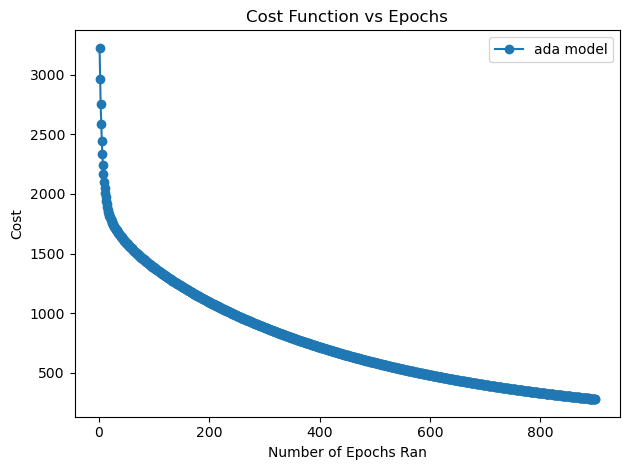

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(range(1, len(ada.cost_)+1), ada.cost_, marker='o', label='ada model')
plt.xlabel('Number of Epochs Ran')
plt.ylabel('Cost')
plt.legend(loc='upper right')
plt.title('Cost Function vs Epochs')
plt.tight_layout()
#plt.savefig('adaline.png',dpi=300)
plt.show()
#This is plotting how well the models predictions line up with the actual values

### <font color='green'/> 15-TO DO:Model Evaluation and Performance

Use the test set to create the model's predictions. Name the prediction vector **y_pred** as in previous notebooks. Make sure you display the predictions in the **y_pred** vector. Also, print the **true labels** so we can visually compare the two vectors.

**Enter your code in the cell below:**



In [20]:
y_pred = ada.predict(X_test_rescaled)
# putting the dataset into the y_pred variable

print('Predicted labels: {}'.format(y_pred))

print('True labels: {}'.format(y_test))
print(y_pred[:20])

Predicted labels: [1 1 1 ... 0 0 1]
True labels: [1 1 1 ... 0 0 1]
[1 1 1 1 1 1 1 0 0 1 0 0 0 0 1 1 0 1 1 1]


### <font color='green'/> 16-TO DO:Predict the label for a single image

Use class Adaline's built-in *predict method* to test the model's predictive performance for the *second* image in X_test_std. **Display the image, the predicted label and the true label**

**Enter your code in the next two cells below:**

In [21]:
#code for prediction (COMPLETE SENTENCES!)
index=1


prediction = y_pred


prediction[index]

print('The predicted digit is : ',prediction[index])
print('The true digit is {}'.format(y_test[index]))



The predicted digit is :  1
The true digit is 1


The corresponding predicted image is:


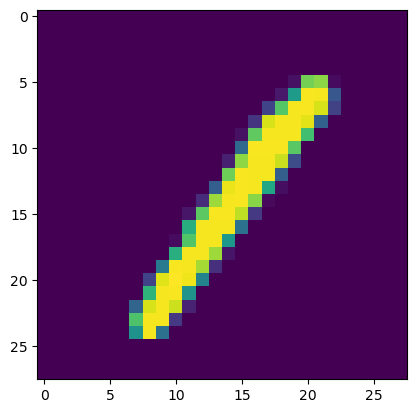

In [22]:
print('The corresponding predicted image is:')
plt.imshow(X_test[index].reshape(28, 28))

### <font color='green'/>17-TO DO:Print the number of misclassifications using numpy 

In [23]:
misclassifications = np.count_nonzero(y_pred != y_test)
# variable set to the number of misclassifications
# as of right now, it is just displaying the original size of the y testing set.
# To troubleshoot, something is wrong around the standard scaling section (Step 12).
# Accuracy diagnostics is all fucked up IDK what to do for that.

print('Number of Musclassifications:{}'.format(misclassifications))

Number of Musclassifications:164


### <font color='green'/> 18-TO DO:Plot some misclassified images
Write code for a simple decision structure that plots five(5) images of some of the predictions that **went wrong**. Do not rewrite the plotting code. Use the code defined earlier. HINT: create an error filter using the numpy code for misclassifications and use that expression to call the plotting function.

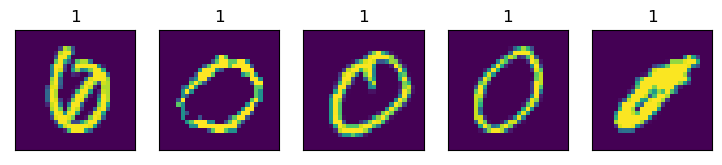

In [40]:
#these are misclassifications, where the model messed up
wrong_images = np.where(y_pred != y_test)
if len(wrong_images) > 0:
    plot_example(X_test[wrong_images], y_pred[wrong_images])


### <font color='green'/> 19-TO DO: Show the *Classification Report* for the`ada` Classification Model

In [25]:
from sklearn import metrics
print("Classification Report")
print("")
classreport = metrics.classification_report(y_test, y_pred)
print(classreport)

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1690
           1       0.93      1.00      0.96      2005

    accuracy                           0.96      3695
   macro avg       0.96      0.95      0.95      3695
weighted avg       0.96      0.96      0.96      3695



### <font color='green'/>20-TO DO: Display the *Pretty Confusion Matrix*  for the`ada` Classification Model
<font color='red'/>NOTE: You have to provide the class labels here.Think!

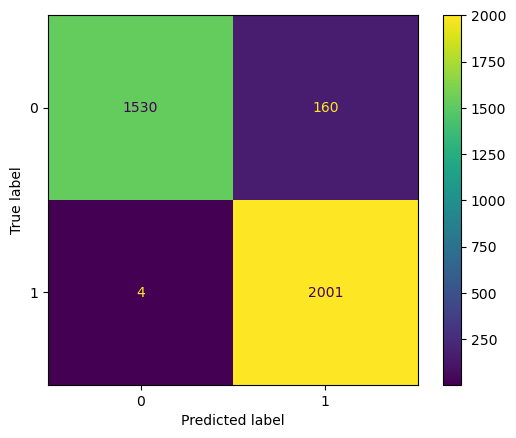

In [26]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels = np.unique(y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = np.unique(y_test))

plt.show()






disp.plot()


## <font color='orange'/>Questions

### <font color='green'/> Q1 (4 points): Using the Standard Scaler

Before you begin, enter the values from the run above where you used MinMaxScaler [Revision: This should be StandardScaler]. Then run the identical code *only changing to the `StandardScaler` [Revision: This should be MinMaxScaler] for scaling the data*. Enter you results below:

- misclassifications using MinMaxScaler = 798

- misclassifications using StandardScaler = 164

<font color='red'/> IMPORTANT: After you complete this question, replace the StandardScaler code with the MinMaxScaler code and use MinMaxScaler for the rest of the project.

### <font color='green'/> Q2 (10 points): Adding an accuracy score method to your Adaline class (accuracy > 90%)
Using **only** numpy (and of course python), modify (enhance) the class Adaline to give it a *built-in* method to return the accuracy of the trained classification mode. Your method **must** behave like scikit-learn's scoring method. That is, a user should be able to call it with code like: `ada.score(X_test_std, y_test)`. After you have modified your code, demonstrate it by calling the method with a print statement in the cell below. Record a copy of your instantiated model (showing parameters you used) in the **markdown** cell below:

In [27]:
#What you call X_test_std, we called X_test_rescaled for this model. Hope that's not a problem. I understand that the std stands for standardized since you're standardizing the values
print("Accuracy:", ada.score(X_test_rescaled, y_test))

Accuracy: 0.9556156968876861


<font color='green'/>Copy and paste ONLY your model here (model MUST have accuracy > 90% ):
    
> adaline model with best performance: AdalineGD(n_iter=900, eta = 0.00000001, random_state=1).fit(X_train_rescaled, y_train)

### <font color='green'/>Q3 (5 points) Build the Scikit Learn Perceptron Classification Model 
In **one** cell below, build and use the [scikit-learn Perceptron classifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html#sklearn.linear_model.Perceptron) to classifiy the subset of the data with the 0, 1 subset of images you used in this exam. Print the accuracy, misclassifications and the confusion matrix.

<font color='red'/>Instantiate the scikit-learn perceptron model with these parameters: `max_iter=50`, `eta=0.001`, `tol = 0.01`, `random_state=0`

In [28]:
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import Perceptron

#eta has to be eta0 to not mess up the code
ppn=Perceptron(max_iter=50, eta0=0.001, tol=0.01, random_state=0)
ppn.fit(X_train_rescaled, y_train)

y_pred = ppn.predict(X_test_rescaled)

Accuracy = ppn.score(X_test_rescaled, y_test)

misclassifications = np.sum(y_test != y_pred)

CM = confusion_matrix(y_test, y_pred)

print("Accuracy is {}".format(Accuracy))

print("Number of misclassifications: {}".format(misclassifications))

print("Confusion Matrix")

print(cm)

Accuracy is 0.9981055480378891
Number of misclassifications: 7
Confusion Matrix
[[1530  160]
 [   4 2001]]


### <font color='green'/>Q4 (4 points) Display the *Pretty* Confusion Matrix for the  Perceptron Classification Model in Q3
Enter your code in **one** cell below. <font color='red'/>WARNING: use a different name for the prediction vector or it will conflict with your previous naming.

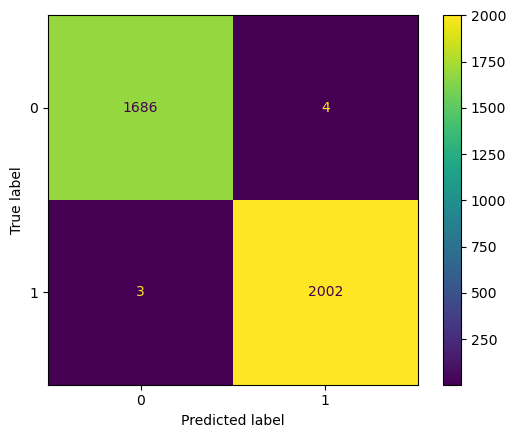

In [29]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#rename y_pred to be something else so it doesn't conflict
y_pred_ppn = ppn.predict(X_test_rescaled)


cm = confusion_matrix(y_test, y_pred_ppn, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

disp.plot()
plt.show()

<center>
    
## <font color='orange'/>Statistics for Evaluating the Performance of Machine Learning Models</h1>

</center>

We can compare two supervised machine learning models using the same training dataset by applying the classical hypothesis testing paradigm. Our measure of model performance is the test-set error rate. Below, we state the problem in the form of a *null hypothesis*.

>There is no significant difference in the test set error rate of two supervised machine learning models, $M_1$ and $M_2$, built with the same training dataset.

Although there are several possible test set scenarios we can use, we will take the approach that allows us to compare performance between models when:
- *the **same** test dataset is used to compare the models, and*
- *the comparison is is based on the overall classification correctness of the models.* 

While this is a simple approach, it would perhaps be more straightforward to compare model performance using **two independent testing datasets selected randomly from a a pool of sample data.** However, this approach is feasible only if there is a large supply of data available from which random test sets can be extracted. Thus, when smaller-sized datasets are all we have to work with, a single test set used on both models is probably the only possibility.


### Comparing Models with Independent Test Data
The simpler approach that we will take is to use a technique that compares the overall classification correctness of the models. *It shoud be noted that this method is equally valid whether we have two independent test datasets or only a single dataset to use with both models.* 

The most general form of the statistic for comparing the performance of two classifier models  $M_1$ and $M_2$ is

\begin{eqnarray}
 P= \frac{|E_{1} - E_{2}|}{\sqrt{q(1-q)(1/n_{1} + 1/n_{2} )}} 
\end{eqnarray}


<div style="width:400px; margin:2px">
  
    
| **where:** |  |  |
|:------|:------|:-----|
$E_1$| is the error rate for model $M_1$| |
|$E_2$|is the error rate for model $M_2$| |
|$ q $| = $\frac{(E_1 + E_2)}{2}$ is the error rate average||
|$n_1$|is the number of instances in test set A||
|$n_2$|is the number of instances in test set B||

</div>
<p>You should note that $q(1-q)$ is the variance score computed using the <b>average</b> of the two error rates. When we have a <em>single</em> test set of size $n$ that we use for both models, then the formula simplifies to:</p>


\begin{eqnarray}
 P= \frac{|E_{1} - E_{2}|}{\sqrt{q(1-q)(2/n )}} 
\end{eqnarray}


With either of the above equations, if, for the value of $P$ we find $P$ $\geq$ 2, then we can be 95% confident that the difference in the test set performance is statistically significant. 

In this project, we shall use this simplified version of the relation since we only have one test dataset for both models.

### <font color='green'/>Q5 (10 points) Comparing the Performance of two Supervised Classification Models

### Model Performance Comparison of two Classifiers

Using the **ada model** (with accuracy>90%) and the **scikit-learn perceptron model** in **Q3**, compare the performance of the models using the above statistic when we only have one test set. To do this you need to calculate (**and print**)  in each cell below, the following:

$E_1$ : the error rate for model $M_1$, your Adaline Model

**Enter your code below:**

In [30]:
E1 = 1 - ada.score(X_test_rescaled, y_test)
print(E1)



0.044384303112313894


$E_2$ is the error rate for model $M_2$, your Scikit-Learn Perceptron Model

**Enter your code below:**

In [31]:
#error rate is 1-accuracy
E2 = 1 - ppn.score(X_test_rescaled, y_test)
print(E2)

0.0018944519621109102


$ q $ = $\frac{(E_1 + E_2)}{2}$ ,  the error rate average

**Enter your code below:**

In [32]:
q = (E1 + E2)/2

print("The error rate average is {}".format(q))

The error rate average is 0.023139377537212402


$n_1$, the number of instances in test set A

**Enter your code below:**

In [33]:
n1 = X_test_rescaled.shape[0]
print("The number of instances in test set A is: {}".format(n1))

The number of instances in test set A is: 3695


$n_2$,  the number of instances in test set B

**Enter your code below:**

In [34]:
#Isn't there only the one test set? That's what the question literally said
n2=n1
print("The number of instances in test set B is: {}".format(n2))

The number of instances in test set B is: 3695


#### Using Python, write a simple decision construct to compute and display $P$, depending on whether  $P$ $\geq$ 2. Use a complete sentence in your output.

**Enter your code below:**

In [35]:
import math

P = (abs(E1 - E2)) / (math.sqrt(q * (1 - q) * (2 / n1)))

if P >= 2:
    print("The P-value is: {}".format(P))
    print("Since the P-value is greater than or equal to 2, we are 95% confident that the difference between the two models' performance is statistically significant.")
else:
    print("The P-value is: {}".format(P))
    print("P is less than 2, so we cannot assert that the difference between the the two models' performance is statistically significant.")

The P-value is: 12.14745490492676
Since the P-value is greater than or equal to 2, we are 95% confident that the difference between the two models' performance is statistically significant.


###### <font color='purple'/>Give a brief comparative summary of the two models and your analysis in the cell below. (Keep it short! 2-4 sentences!)

The ada model had an accuracy of .955, and the ppn model had an accuracy of .998. While both very accurate, the perceptron model was almost perfect. The perceptron model only had 7 misclassifications, whereas the adaline had 164. This means that the perceptron model is, at least for images of "0" and "1", shown to be better at predicting the displayed number than the ADALINE model. 

### <font color='green'/>Q6 (6 points) Model Persistence - Save/Load the trained classifier

### <font color='orange'> Pickle (serialize) and save the trained *adaline* classifier to a folder. 
Enter your code in the cell below.

In [36]:
import pickle
import os
saved_classifier = ada
dest = os.path.join('classifier', 'pkl_objects')
if not os.path.exists(dest):
    os.makedirs(dest)
    
pickle.dump(saved_classifier, open(os.path.join(dest, 'classifier.pkl'), 'wb'), protocol=4)

### <font color='orange'> Load the saved trained classifier into memory
Enter your code in the cell below.

In [37]:
import pickle
import re
import os

os.chdir('classifier')
classifier_reloaded = pickle.load(open(os.path.join('pkl_objects', 'classifier.pkl'), 'rb'))

### <font color='orange'> Test the re-loaded classifier
Use the re-loaded classifier to classify an image and compare its classification to the true value.  Use an image from the normalized test set with <font color='red'>index = 25</font>. Use complete sentences in the output for the classifier's prediction such as "The reloaded classifier predicts the image is number __".
    
Enter your code in the cell below.

In [38]:
#Pulling the classifier back out of the file for testing
classifier_reloaded = pickle.load(open(os.path.join('pkl_objects', 'classifier.pkl'), 'rb'))
trial_image = X_test_rescaled[[25], :]


print("the reloaded classifier has an accuracy of: {}".format(classifier_reloaded.score(X_test_rescaled, y_test)))
print("this is the same as the ada model, which has accuracy: {}".format(ada.score(X_test_rescaled, y_test)))

print("The reloaded classifier predicts the trial image is a {}".format(classifier_reloaded.predict(trial_image)))

print("The actual image at index 25 is the number {}".format(y_test[25]))

the reloaded classifier has an accuracy of: 0.9556156968876861
this is the same as the ada model, which has accuracy: 0.9556156968876861
The reloaded classifier predicts the trial image is a [0]
The actual image at index 25 is the number 0


### <font color='green'/>Q7 (6 points) Predictions with images (from Adaline)
Use your prediction vector, y_pred, **from ada (when accuracy > 90%)** to display the first twelve(12) images and the predictions. Display these on 3 rows with 4 images per row .

<center>
    
# <font color='red'/>End of Exam!
    
</center>

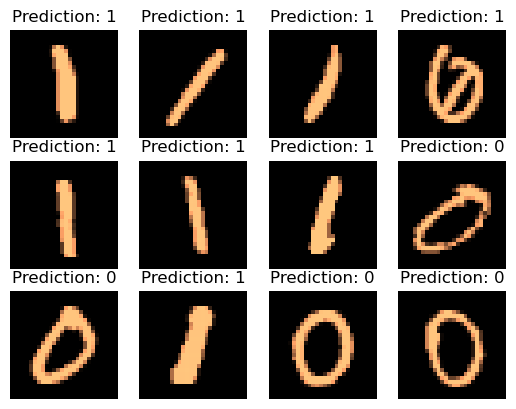

In [39]:
#He did this in class, it's in notes
y_pred = ada.predict(X_test_rescaled)

#combine the images and predictions for the original test set, not rescaled
image_predict = list(zip(X_test.reshape(len(X_test), 28,28), y_pred[:12]))

for i, (image, prediction) in enumerate(image_predict[:12]):
    plt.subplot(3, 4, i + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.copper, interpolation='nearest')
    plt.title("Prediction: {}".format(prediction))
  

plt.show()